In [85]:
import pandas as pd
import numpy as np
from pathlib import Path

import umap
import hdbscan
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import TruncatedSVD
from clustering.hdbscan_optimize import optimize_umap_hdbscan_auto
from visualization.samples_plot import show_clustering_samples
from visualization.plot import plot_clustering_on_umap
from hdbscan.validity import validity_index


PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

1664


In [52]:
embedding_l2 = Normalizer(norm="l2").fit_transform(embedding)

pca_95 = PCA(n_components=0.95)
pca_95_embedding = pca_95.fit_transform(embedding_l2)

In [53]:
MIN_DIST = 0.05
CLUSTER_SELECTION_METHOD = "eom"

best = optimize_umap_hdbscan_auto(
    embedding,
    n_runs=20,

    min_dist=MIN_DIST,
    min_clusters=2,
    max_clusters=10,
    max_noise=0.33,

    min_valid_run_ratio=0.80,
    min_mean_ari=0.50,
    min_mean_dbcv=0.3,

    dbcv_weight=0.50,
    valid_run_ratio_weight=0.35,
    noise_weight=0.15,

    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    max_auto_param_combinations=100,
)

best_params = best["best_params"]
best_n_components = best["best_n_components"]

if best_n_components is None:
    raise ValueError("No suitable number of components found for UMAP.")

print(best_params)

{'umap': {'n_neighbors': 34, 'min_dist': 0.05, 'metric': 'cosine', 'n_components': 50}, 'hdbscan': {'metric': 'euclidean', 'min_cluster_size': 51, 'min_samples': 10, 'cluster_selection_method': 'eom'}, 'constraints': {'min_clusters': 2, 'max_clusters': 10, 'max_noise': 0.33, 'min_valid_run_ratio': 0.8, 'min_mean_ari': 0.5, 'min_mean_dbcv': 0.3}, 'selection': {'metric': 'combined_score', 'dbcv_weight': 0.5, 'valid_run_ratio_weight': 0.35, 'noise_weight': 0.15, 'single_cluster_dbcv_for_score': 0.0}}


In [427]:
from sklearn.preprocessing import normalize

X_reduced_variance = VarianceThreshold(threshold=1e-8).fit_transform(embedding)
print("Shape dopo Variance threshold:", X_reduced_variance.shape)

X_reduced_variance_l2 = normalize(X_reduced_variance, norm="l2")
svd = TruncatedSVD(
    n_components=100,
    algorithm="randomized",
    n_iter=10,
    n_oversamples=20,
    random_state=42,
)

X_svd = svd.fit_transform(X_reduced_variance_l2)
print("Shape dopo SVD:", X_svd.shape)

Shape dopo Variance threshold: (677, 1271)
Shape dopo SVD: (677, 100)


In [437]:
#umap_params = best_params["umap"]

X_svd_l2 = normalize(X_svd, norm="l2")

umap_embedding = umap.UMAP(
    n_neighbors=int(0.075 * n_samples),        #umap_params["n_neighbors"],
    min_dist=0.05,               #umap_params["min_dist"],
    n_components=20,       #umap_params["n_components"],
    metric="cosine"         #umap_params["metric"],
).fit_transform(X_svd_l2)

In [438]:
hdbscan_params = best_params["hdbscan"]

CLUSTER_SELECTION_METHOD = "eom"

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=round(0.03 * n_samples),               #hdbscan_params["min_cluster_size"],
    min_samples=5,            #round(0.01 * n_samples),  #          hdbscan_params["min_samples"],
    metric="euclidean",         #hdbscan_params["metric"],
    cluster_selection_method=CLUSTER_SELECTION_METHOD       #hdbscan_params["cluster_selection_method"]
)

labels = clusterer.fit_predict(umap_embedding)

probabilities = clusterer.probabilities_    # How much a points belong to the assigned cluster
outlier_scores = clusterer.outlier_scores_  # How much a point is anomalous compared to the rest of the data

In [439]:
cluster_ids = sorted(label for label in np.unique(labels) if label != -1)

if len(cluster_ids) >= 2:
    dbcv_global, dbcv_per_cluster = validity_index(
        np.asarray(umap_embedding, dtype=np.float64),
        labels,
        metric="euclidean",
        per_cluster_scores=True,
    )
else:
    dbcv_global = np.nan
    dbcv_per_cluster = [np.nan for _ in cluster_ids]

dbcv_by_cluster = dict(zip(cluster_ids, dbcv_per_cluster))

cluster_dbcv_summary = pd.DataFrame(
    [
        {
            "cluster": int(cluster_id),
            "size": int(np.sum(labels == cluster_id)),
            "dbcv": float(dbcv_by_cluster[cluster_id]),
        }
        for cluster_id in cluster_ids
    ]
)

if np.any(labels == -1):
    cluster_dbcv_summary = pd.concat(
        [
            cluster_dbcv_summary,
            pd.DataFrame([
                {
                    "cluster": -1,
                    "size": int(np.sum(labels == -1)),
                    "dbcv": np.nan,
                }
            ]),
        ],
        ignore_index=True,
    )

print(f"DBCV globale: {dbcv_global:.4f}")
display(cluster_dbcv_summary.sort_values("cluster").reset_index(drop=True))

DBCV globale: 0.2242


,cluster,size,dbcv
0,-1,159,NaN
1,0,33,0.360295
2,1,255,0.274191
3,2,133,0.315021
4,3,55,0.186297
5,4,42,0.424395


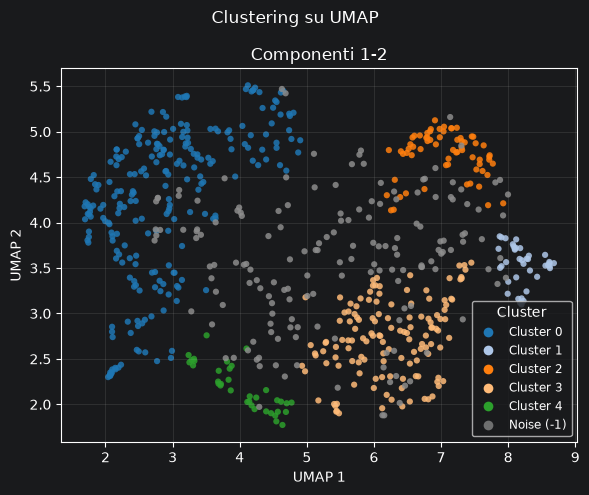

(<Figure size 600x500 with 1 Axes>,
 (<Axes: title={'center': 'Componenti 1-2'}, xlabel='UMAP 1', ylabel='UMAP 2'>,))

In [424]:
plot_clustering_on_umap(
    X_svd_l2,
    labels,
    min_dist=0.05,
    n_neighbors=int(0.075 * n_samples)        #umap_params["n_neighbors"],
)

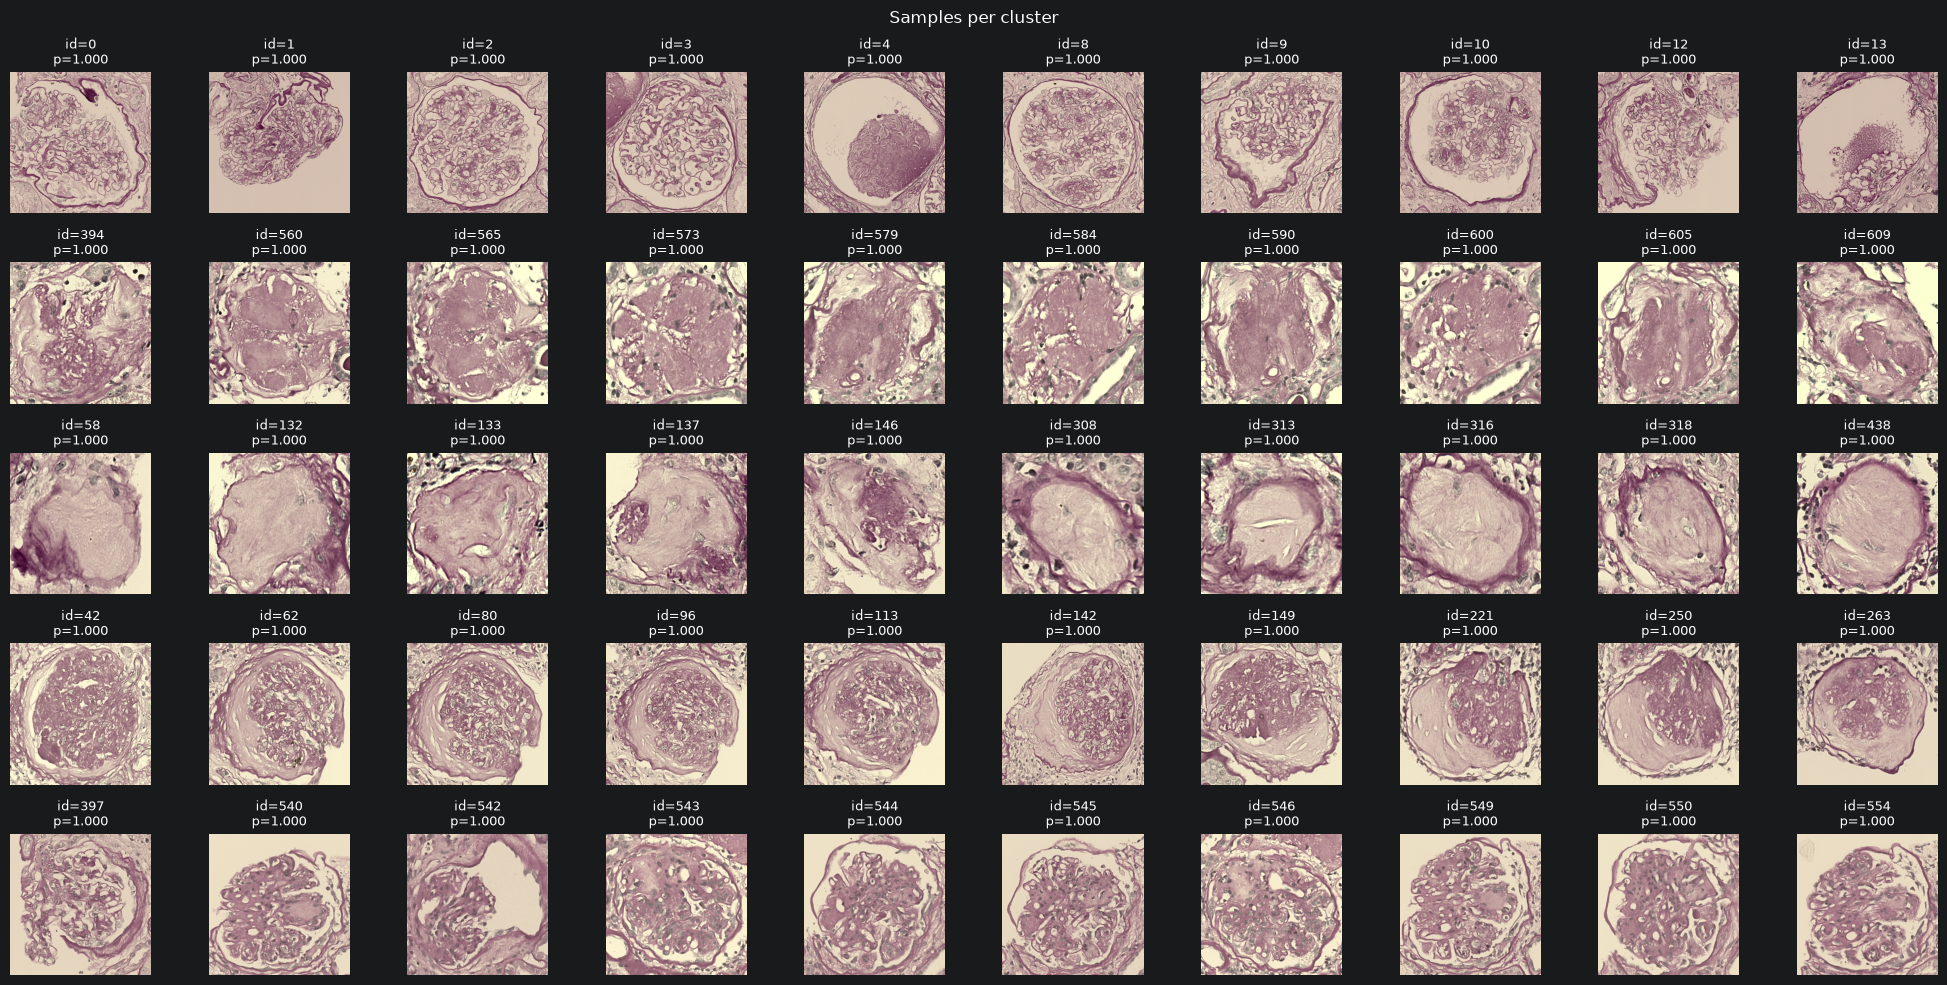

In [425]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=labels,
    probabilities=clusterer.probabilities_,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [59]:
cols = [
    "n_components",
    "successful_runs",
    "valid_runs",
    "valid_run_ratio",
    "mean_dbcv",
    "mean_ari",
    "mean_dbcv_all",
    "mean_ari_all",
    "mean_n_clusters_all",
    "mean_noise_ratio_all",
    "valid_for_selection",
]

print(best["results"][cols].sort_values("n_components"))

print(
    best["run_details"]
    .groupby(["n_components", "constraint_reason"])
    .size()
    .unstack(fill_value=0)
)

    n_components  successful_runs  valid_runs  valid_run_ratio  mean_dbcv  \
10            10               20          18             0.90   0.306572   
25            10               20          20             1.00   0.225733   
21            10               20          19             0.95   0.286313   
18            10               20          20             1.00   0.289447   
47            10               20          17             0.85   0.210301   
..           ...              ...         ...              ...        ...   
69            50               20          12             0.60   0.291806   
94            50               20           6             0.30   0.305119   
93            50               20           8             0.40   0.224783   
92            50               20           8             0.40   0.226367   
96            50               20           7             0.35   0.267215   

    mean_ari  mean_dbcv_all  mean_ari_all  mean_n_clusters_all  \
10  0.689

In [214]:
from sklearn.metrics import pairwise_distances


def pair_rank_report(X, idx_a, idx_b, metric="cosine", name="space"):
    """
    Dice quanto idx_b è vicino a idx_a nello spazio X.
    rank = 1 significa vicino più vicino.
    rank alto significa lontano.
    """
    D = pairwise_distances(X, X[[idx_a]], metric=metric).ravel()

    order = np.argsort(D)
    order = order[order != idx_a]  # rimuove sé stesso

    rank_b = np.where(order == idx_b)[0][0] + 1
    dist_ab = D[idx_b]

    percent_rank = rank_b / (len(X) - 1) * 100

    print(f"\n{name}")
    print(f"metric: {metric}")
    print(f"distanza {idx_a} -> {idx_b}: {dist_ab:.4f}")
    print(f"rank del secondo rispetto al primo: {rank_b}/{len(X)-1}")
    print(f"percentile rank: {percent_rank:.2f}%")

    return {
        "space": name,
        "distance": dist_ab,
        "rank": rank_b,
        "percent_rank": percent_rank,
    }

In [216]:
ID_SCLEROTIC = 4
ID_OPEN = 3

In [331]:
# Distanza originale tra due punti nello spazio embedding
report_pre = pair_rank_report(
    embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="PRE-UMAP"
)

post_variance_threshold = pair_rank_report(
    X_reduced_variance,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-VarianceThreshold"
)

post_truncated_svd = pair_rank_report(
    X_svd,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-TruncatedSVD"
)

post_umap = pair_rank_report(
    umap_embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="euclidean",
    name="POST-UMAP"
)


PRE-UMAP
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-VarianceThreshold
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-TruncatedSVD
metric: cosine
distanza 4 -> 3: 0.2709
rank del secondo rispetto al primo: 215/676
percentile rank: 31.80%

POST-UMAP
metric: euclidean
distanza 4 -> 3: 2.1678
rank del secondo rispetto al primo: 178/676
percentile rank: 26.33%
